# Agglomerative Clustering

In [3]:
import os

import pandas as pd 
import numpy as np 

import sklearn
from sklearn import decomposition
from sklearn import cluster
from sklearn import metrics

from scipy.cluster.hierarchy import dendrogram
from scipy.spatial.distance import cdist

import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import matplotlib.cm as cm

In [4]:
# Credits: https://www.angela1c.com/projects/iris_project/downloading-iris/
csv_url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data'
# using the attribute information as the column names
col_names = ['Sepal_Length','Sepal_Width','Petal_Length','Petal_Width','Species']
iris =  pd.read_csv(csv_url, names = col_names)
iris

,Sepal_Length,Sepal_Width,Petal_Length,Petal_Width,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [5]:
y_true = iris[["Species"]]
y_true

,Species
0,Iris-setosa
1,Iris-setosa
2,Iris-setosa
3,Iris-setosa
4,Iris-setosa
...,...
145,Iris-virginica
146,Iris-virginica
147,Iris-virginica
148,Iris-virginica


On simule un jeu de données non annotées.

In [6]:
X = iris.drop(["Species"], axis = 1)
X

,Sepal_Length,Sepal_Width,Petal_Length,Petal_Width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


On utilise une analyse en composantes principales (ACP) pour réduire la dimension des données, ce qui facilite leur visualisation. On verra comment fonctionne l'ACP dans un autre TP.

In [7]:
pca = decomposition.PCA(n_components = 2)
pca_X = pca.fit_transform(X)

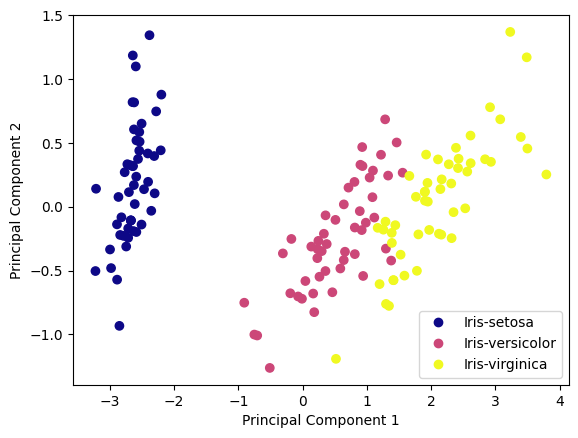

In [8]:
classes = np.unique(y_true)
str2int = dict((k, v) for (v, k) in enumerate(classes))
colors =  np.vectorize(
# <CORRECTION>
    str2int.get
    )(
    y_true
# </CORRECTION>
)

fig, ax = plt.subplots()
scatter = plt.scatter(pca_X[:, 0], pca_X[:, 1], c=colors, cmap='plasma')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(handles=scatter.legend_elements()[0], 
           labels=list(classes))
plt.show()

In [9]:
# <CORRECTION>
hier_clustering = cluster.AgglomerativeClustering(n_clusters=None, distance_threshold=0)
hier_clustering.fit(X)
# </CORRECTION>

,n_clusters,None
,metric,'euclidean'
,memory,None
,connectivity,None
,compute_full_tree,'auto'
,linkage,'ward'
,distance_threshold,0
,compute_distances,False


In [10]:
def leaves_merged_nodes(children, it):
    """Compute the leaves that belong tp the merged clusters at a given iteration.
    Args:
        children (np.ndarray): children_ attribute of sklearn.cluster.AgglomerativeClustering
        it (int): iteration of the hierarchical algorithm
    """
    # <CORRECTION>
    n = children.shape[0] + 1
    merged = children[it]
    if merged[0] < n and merged[1] < n:
        return [merged[0], merged[1]]
    else:
        if merged[0] < n:
            leaves_2 = leaves_merged_nodes(children, merged[1] - n)
            return [merged[0]] + leaves_2
        elif merged[1] < n:
            leaves_1 = leaves_merged_nodes(children, merged[0] - n)
            return leaves_1 + [merged[1]] 
        else:
            leaves_1 = leaves_merged_nodes(children, merged[0] - n)
            leaves_2 = leaves_merged_nodes(children, merged[1] - n)
            return leaves_1 + leaves_2
    # </CORRECTION>

In [29]:
save = True
folder = '/home/romain/Documents/agro_paris_tech/cours/ML-2A-source/cours-clustering/figures/hier'

labels = np.arange(X.shape[0])
np.random.shuffle(labels)

fig, ax = plt.subplots()
scatter = plt.scatter(pca_X[:, 0], pca_X[:, 1], color='black')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Agglomerative Clustering')
if save:
    plt.savefig(os.path.join(folder, 'agg_cl_it-0.png'), dpi=200, bbox_inches='tight', pad_inches=0)
    plt.close()
else:
    plt.show()

fig, ax = plt.subplots()
scatter = plt.scatter(pca_X[:, 0], pca_X[:, 1], c=labels, cmap='plasma')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Agglomerative Clustering - it = 0')
if save:
    plt.savefig(os.path.join(folder, 'agg_cl_it-00.png'), dpi=100, bbox_inches='tight', pad_inches=0)
    plt.close()
else:
    plt.show()

for it in range(len(hier_clustering.children_)):
    leaves = leaves_merged_nodes(hier_clustering.children_, it)
    labels[np.array(leaves)] = len(hier_clustering.children_) + 1 + it
    
    classes = np.unique(labels)
    new_classes = dict((v, k) for (k, v) in zip(np.arange(len(classes)), classes))
    labels = np.vectorize(new_classes.get)(labels)


         
    fig, ax = plt.subplots()
    scatter = plt.scatter(pca_X[:, 0], pca_X[:, 1], c=labels, cmap='plasma')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.title(f'Agglomerative Clustering - it = {it + 1}')
    if save:
        plt.savefig(os.path.join(folder, f'agg_cl_it-{it+1}'), dpi=100, bbox_inches='tight', pad_inches=0)
        plt.close()
    elif (it + 1) % 40 == 0 or it == len(hier_clustering.children_) - 1:
        plt.show()
    else:
        plt.close()

In [15]:
import imageio.v2 as imageio

images = []
file_names = os.listdir(folder)
file_names = sorted(file_names, key=lambda x: int(x.split('.')[0].split('-')[-1]))
for i, file_name in enumerate(file_names):
    if file_name.endswith('.png'):
        file_path = os.path.join(folder, file_name)
        images.append(imageio.imread(file_path))

imageio.mimsave('/home/romain/Documents/agro_paris_tech/cours/ML-2A-source/cours-clustering/figures/agg_cl.gif', images)

In [16]:
def plot_dendrogram(model, **kwargs):
    # Create linkage matrix and then plot the dendrogram

    # create the counts of samples under each node
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count
    
    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    # Plot the corresponding dendrogram
    dendrogram(linkage_matrix, **kwargs)

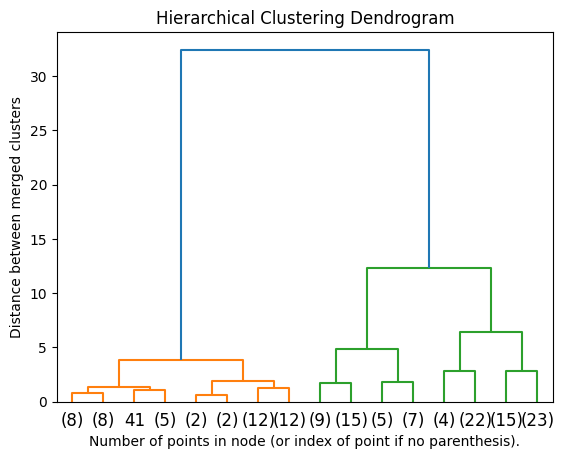

In [17]:
plot_dendrogram(hier_clustering, truncate_mode="level", p=3)
plt.xlabel("Number of points in node (or index of point if no parenthesis).")
plt.ylabel("Distance between merged clusters")
plt.title("Hierarchical Clustering Dendrogram")
plt.savefig(os.path.join(folder, 'agg_cl_dendogram.pdf'), dpi=200, bbox_inches='tight', pad_inches=0)

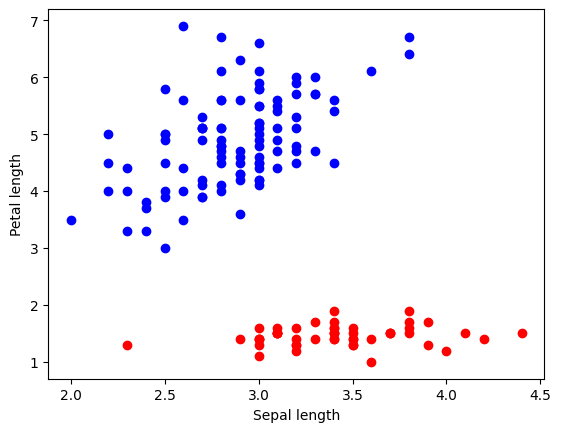

In [28]:
X2 = X.to_numpy()[:, 1:3]
cl_dbscan = cluster.DBSCAN(eps=1, min_samples=5).fit(X2)
# np.unique(cl_dbscan.labels_)
components = X2[cl_dbscan.core_sample_indices_]
labels_compo = cl_dbscan.labels_[cl_dbscan.core_sample_indices_]
classes = np.unique(cl_dbscan.labels_)
fig, ax = plt.subplots()

if -1 in classes:
    colors = ['black', 'red', 'blue', 'green']
else:
    colors = ['red', 'blue', 'green']

for i, class_id in enumerate(classes):
    data = X2[cl_dbscan.labels_ == class_id]
    comp = components[labels_compo == class_id]
    plt.scatter(data[:, 0], data[:, 1], color=colors[i], marker='+')
    if class_id >= 0:
        plt.scatter(comp[:, 0], comp[:, 1], color=colors[i], alpha=1)
        
plt.xlabel('Sepal length')
plt.ylabel('Petal length')
plt.savefig('/home/romain/Documents/agro_paris_tech/cours/ML-2A-source/cours-clustering/figures/dbscan_1_5.pdf', dpi=200, bbox_inches='tight', pad_inches=0)


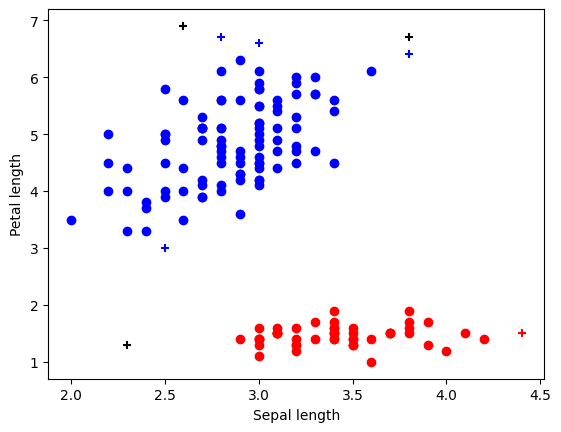

In [23]:
X2 = X.to_numpy()[:, 1:3]
cl_dbscan = cluster.DBSCAN(eps=0.5, min_samples=5).fit(X2)
# np.unique(cl_dbscan.labels_)
components = X2[cl_dbscan.core_sample_indices_]
labels_compo = cl_dbscan.labels_[cl_dbscan.core_sample_indices_]
classes = np.unique(cl_dbscan.labels_)
fig, ax = plt.subplots()

if -1 in classes:
    colors = ['black', 'red', 'blue', 'green']
else:
    colors = ['red', 'blue', 'green']
for i, class_id in enumerate(classes):
    data = X2[cl_dbscan.labels_ == class_id]
    comp = components[labels_compo == class_id]
    plt.scatter(data[:, 0], data[:, 1], color=colors[i], marker='+')
    if class_id >= 0:
        plt.scatter(comp[:, 0], comp[:, 1], color=colors[i], alpha=1)
        
plt.xlabel('Sepal length')
plt.ylabel('Petal length')
plt.savefig('/home/romain/Documents/agro_paris_tech/cours/ML-2A-source/cours-clustering/figures/dbscan_05_5.pdf', dpi=200, bbox_inches='tight', pad_inches=0)


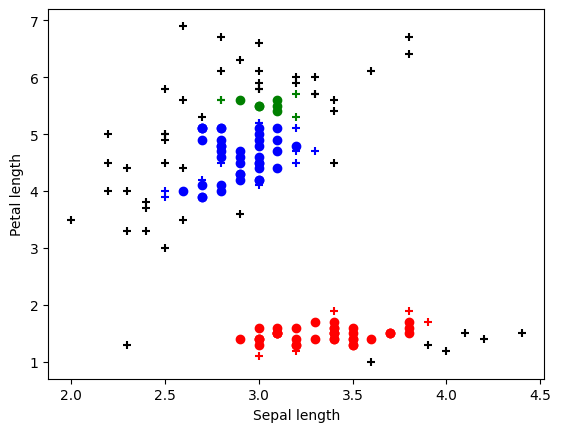

In [27]:
X2 = X.to_numpy()[:, 1:3]
cl_dbscan = cluster.DBSCAN(eps=0.2, min_samples=5).fit(X2)
# np.unique(cl_dbscan.labels_)
components = X2[cl_dbscan.core_sample_indices_]
labels_compo = cl_dbscan.labels_[cl_dbscan.core_sample_indices_]
classes = np.unique(cl_dbscan.labels_)
fig, ax = plt.subplots()

if -1 in classes:
    colors = ['black', 'red', 'blue', 'green']
else:
    colors = ['red', 'blue', 'green']
for i, class_id in enumerate(classes):
    data = X2[cl_dbscan.labels_ == class_id]
    comp = components[labels_compo == class_id]
    plt.scatter(data[:, 0], data[:, 1], color=colors[i], marker='+')
    if class_id >= 0:
        plt.scatter(comp[:, 0], comp[:, 1], color=colors[i], alpha=1)
        
plt.xlabel('Sepal length')
plt.ylabel('Petal length')
plt.savefig('/home/romain/Documents/agro_paris_tech/cours/ML-2A-source/cours-clustering/figures/dbscan_02_5.pdf', dpi=200, bbox_inches='tight', pad_inches=0)
